# Bitcoin Next-Day Price Forecasting: LSTMs vs Honest Baselines

**Maanak Gadia & Kinjal Ahuja** · originally a 2023 Nirma University project, rebuilt in 2026

This notebook revisits our 2023 LSTM Bitcoin forecaster and asks one question properly:
**does a deep learning model forecast tomorrow's Bitcoin price better than simply assuming tomorrow's price equals today's?**

It is structured in five parts:

1. **Audit of the 2023 version**: a bug in converting predictions back to dollars hid how the model really performed.
2. **Data**: 11 years of daily prices and some properties that make them hard to forecast.
3. **Evaluation design**: walk-forward testing over 7 separate years, with every model scored the same way.
4. **Models**: three baselines, the original 2023 LSTM design (with the bug fixed), and an LSTM redesigned to forecast returns.
5. **Results and conclusions**.

All modelling code lives in `src/btcforecast/`, and `scripts/run_experiments.py` runs the same experiment from the command line.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from btcforecast.audit import audit
from btcforecast.data import load_prices
from btcforecast.evaluate import price_metrics, run_walk_forward, summarise, walk_forward_folds
from btcforecast.experiment import TEST_YEARS, build_models
from btcforecast.features import add_features
from btcforecast.plots import findings, plot_folds, plot_relative_mae, plot_zoom, to_markdown

try:
    import tensorflow as tf
    from btcforecast import lstm
    HAS_TF = True
    print("TensorFlow", tf.__version__)
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed: saved results will be loaded instead of training.")

feat = add_features(load_prices())
print(f"{len(feat):,} days of data: {feat.index[0].date()} to {feat.index[-1].date()}")

TensorFlow 2.21.0
4,160 days of data: 2015-01-02 to 2026-05-23


## 1. Audit of the 2023 version

The 2023 notebook trained a 4-layer LSTM on one year of daily prices (Apr 2022 – Apr 2023), scaled to 0–1 with `MinMaxScaler`, and reported **MAE = 1,765.90** and **"accuracy" = 72.95%**.

The "real" prices in its chart ranged from about \$700 to \$11,500, but Bitcoin actually traded between **\$16,600 and \$30,500** over that period. The cause was the conversion back to dollars:

```python
scale = 1/5.18164146e-05      # hard-coded factor
Y_pred = Y_pred * scale        # should be: scaler.inverse_transform(Y_pred)
```

That line has two errors:

- It drops the `+ data_min` term of the MinMax inverse, which shifts every price down by the training-period minimum.
- It uses a factor that isn't the scaler's own factor for the target column (`scaler.scale_[0] = 4.05414372e-05`), which shrinks every value by a further 22%.

`btcforecast.audit` confirms this diagnosis using only numbers the 2023 notebook printed. It recovers the training minimum from the first test day, then reconstructs the last test day's price independently.

In [2]:
a = audit()
pd.Series(a).map(lambda v: f"{v:,.2f}").to_frame("value")

,value
recovered_training_min_open,"15,782.30"
last_day_reconstructed,"27,528.96"
last_day_actual,"27,528.96"
reconstruction_error_usd,0.00
printed_mae_usd,"1,765.90"
true_mae_usd,"2,257.02"
printed_accuracy,0.73


Reconstructing the last test day lands on the true price to the cent, so the diagnosis is confirmed. Since both series went through the same wrong conversion, the dropped offset cancels in the MAE and only the factor matters. The corrected MAE is therefore about **\$2,257**.

The more important question is how that compares with doing nothing clever at all:

In [3]:
test_days = feat.loc["2023-01-02":"2023-04-25"]
prev = feat["price"].shift(1).loc[test_days.index]
naive_mae = price_metrics(test_days["price"], prev, prev)["MAE"]

print(f"2023 LSTM, corrected MAE:          ${a['true_mae_usd']:,.0f}")
print(f"Naive 'tomorrow = today' MAE:      ${naive_mae:,.0f}")
print(f"LSTM error relative to naive:      {a['true_mae_usd'] / naive_mae:.1f}x")

2023 LSTM, corrected MAE:          $2,257
Naive 'tomorrow = today' MAE:      $472
LSTM error relative to naive:      4.8x


**Over the same test days, the 2023 LSTM's error was several times larger than a forecast that simply repeats today's price.** (The naive figure uses Coin Metrics daily prices, while the 2023 target was Yahoo's open price. The two differ slightly, but not nearly enough to change this conclusion.)

The 2023 evaluation had other weaknesses too:

- There were only **191 training windows**, which is far too few for a 180K-parameter network.
- It used **one** train/test split, so results depended on a single four-month period.
- There was **no baseline** to compare against.
- **"Accuracy" = 1 − MAE / mean price** isn't a meaningful metric: on this test period, a model that always predicted the average price would score about 88%, higher than the LSTM's reported 73%.

The rest of this notebook fixes each of these.

## 2. Data

Daily Bitcoin reference prices and reported spot trading volume from [Coin Metrics Community Data](https://github.com/coinmetrics/data) (CC BY-NC 4.0), January 2015 to May 2026.

The two model inputs are the **daily log return**, `ln(P_t / P_{t-1})`, and the **daily log change in volume**. Both are close to stationary, unlike the raw price, which rose more than 200-fold over this period.

Daily log return: mean 0.132%, std 3.54%, excess kurtosis 11.9, worst day -47.1%, best day 22.4%


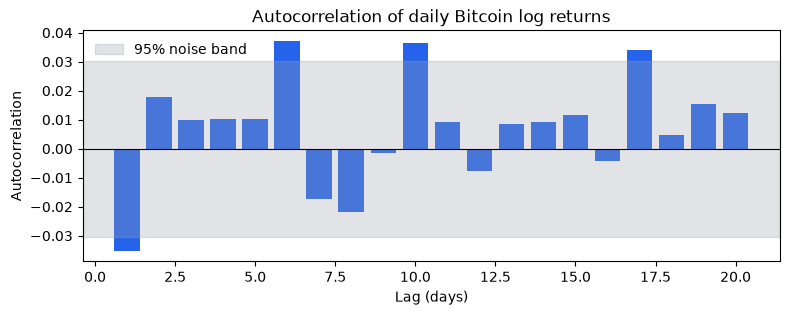

In [4]:
r = feat["ret"]
print(f"Daily log return: mean {r.mean():.3%}, std {r.std():.2%}, "
      f"excess kurtosis {r.kurt():.1f}, worst day {r.min():.1%}, best day {r.max():.1%}")

acf = pd.Series({lag: r.autocorr(lag) for lag in range(1, 21)})
band = 1.96 / np.sqrt(len(r))
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(acf.index, acf.values, color="#2563eb")
ax.axhspan(-band, band, color="#9ca3af", alpha=0.3, label="95% noise band")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="Lag (days)", ylabel="Autocorrelation",
       title="Autocorrelation of daily Bitcoin log returns")
ax.legend(frameon=False)
plt.show()

Two properties matter here:

- **Fat tails.** The excess kurtosis is about 12, where a normal distribution has 0, and single days reach double-digit percentage moves. This is why the redesigned LSTM uses a Huber loss, which stops a handful of crash days from dominating training.
- **Almost no linear memory.** Every autocorrelation stays within about ±0.04 of zero. Yesterday's return tells you almost nothing about today's. A model can only beat the naive forecast if it finds *non-linear* structure, and that sets a high bar.

## 3. Evaluation design: walk-forward testing

Every model is evaluated on **7 separate test years (2020 to May 2026)**. For each test year, it is trained only on the data before it. This covers very different conditions: the March 2020 crash, the 2021 bull run, the 2022 bear market and the 2024–25 rally.

Leakage controls are enforced in code and covered by `tests/test_pipeline.py`:

- The input window for day *j* ends on day *j − 1*.
- Scalers are fitted only on data before the test year.
- Early stopping validates on the most recent 15% of the *training* period.

Every model is scored the same way: as a price forecast for the next day, in US dollars.

In [5]:
folds = walk_forward_folds(feat, 30, TEST_YEARS)
pd.DataFrame([{
    "test year": y,
    "train from": feat.index[tr[0]].date(), "train to": feat.index[tr[-1]].date(),
    "train days": len(tr), "test days": len(te),
} for y, tr, te in folds]).set_index("test year")

,train from,train to,train days,test days
test year,,,,
2020,2015-02-01,2019-12-31,1795,366
2021,2015-02-01,2020-12-31,2161,365
2022,2015-02-01,2021-12-31,2526,365
2023,2015-02-01,2022-12-31,2891,365
2024,2015-02-01,2023-12-31,3256,366
2025,2015-02-01,2024-12-31,3622,365
2026,2015-02-01,2025-12-31,3987,143


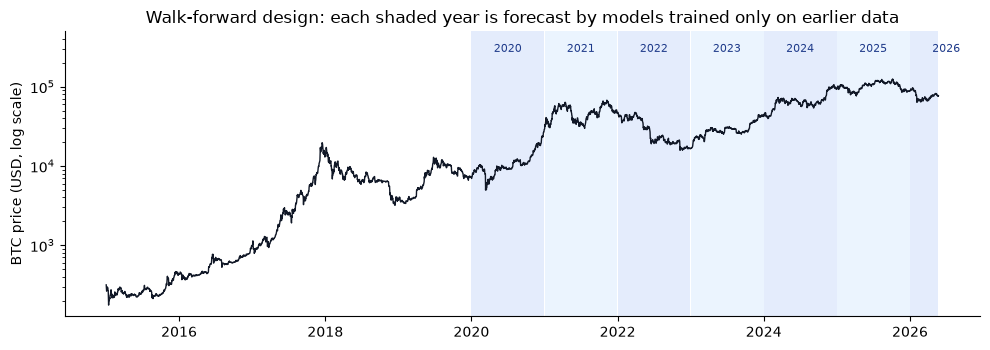

In [6]:
plot_folds(feat, None, TEST_YEARS)
plt.show()

## 4. Models

| Model | Input | Predicts | Notes |
|---|---|---|---|
| **Naive** | – | tomorrow = today | The benchmark every model must beat |
| **Drift** | – | average historical daily return | Tests whether a trend alone helps |
| **Ridge** | last 30 days of returns + volume changes | next-day return | Linear model; regularisation tuned by time-series CV within training data |
| **LSTM (2023 design)** | last 60 days of MinMax-scaled price | next-day price level | The original 4-layer architecture (50/60/80/120 units), inverse scaling fixed |
| **LSTM (returns)** | last 30 days of standardised returns + volume changes | next-day return | 1 LSTM layer (32 units), dropout, Huber loss, early stopping, 3-seed ensemble |

**Why switch to predicting returns?** A model trained on MinMax-scaled *price levels* never sees a value above 1 during training. When prices then break above the training range, as in the 2021 and 2024 rallies, it has to extrapolate, and it tends to lag. Returns stay in a similar range across all periods, so the model faces the same kind of problem in every year.

In [7]:
if HAS_TF:
    lstm.build_return_lstm(window=30, n_features=2).summary()
    lstm.build_original_lstm(window=60).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,513 (17.63 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 60)         │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 80)         │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Results

Training every model across all 7 years takes roughly 20–40 minutes on a laptop CPU. Set `RUN_TRAINING = False` to load the saved results in `results/predictions.csv` instead.

In [8]:
RUN_TRAINING = False

if RUN_TRAINING:
    models, windows = build_models(skip_lstm=False)
    preds = run_walk_forward(feat, models, windows, TEST_YEARS)
else:
    preds = pd.read_csv(ROOT / "results" / "predictions.csv", parse_dates=["date"])

by_fold, overall = summarise(preds)
display(Markdown(to_markdown(overall)))
display(Markdown(findings(overall)))

| Model | MAE (USD) | RMSE (USD) | MAPE | Direction | DM vs naive (p) |
|---|---:|---:|---:|---:|---:|
| Naive | 965 | 1,505 | 2.12% | – | – |
| Drift | 967 | 1,509 | 2.12% | 51.9% | +1.26 (0.208) |
| Ridge | 967 | 1,508 | 2.13% | 51.9% | +1.22 (0.222) |
| LSTM (returns) | 968 | 1,509 | 2.13% | 52.1% | +0.65 (0.514) |
| LSTM (2023 design) | 6,809 | 10,442 | 13.38% | 49.3% | +24.15 (0.000) |

- **Drift**: MAE +0.2% vs naive; not significantly different from naive (Diebold-Mariano p = 0.208).
- **Ridge**: MAE +0.2% vs naive; not significantly different from naive (Diebold-Mariano p = 0.222).
- **LSTM (returns)**: MAE +0.3% vs naive; not significantly different from naive (Diebold-Mariano p = 0.514).
- **LSTM (2023 design)**: MAE +605.7% vs naive; significantly worse than naive (Diebold-Mariano p = 0.000).

**How to read the table:** MAE and RMSE are the average next-day price error in US dollars across all test days (2020 to May 2026). *Direction* is the percentage of days on which the model called the direction of the move correctly (50% is a coin flip). The *Diebold-Mariano* test checks whether a model's errors differ from the naive forecast's by more than chance. A negative statistic with p < 0.05 would mean a model is genuinely better.

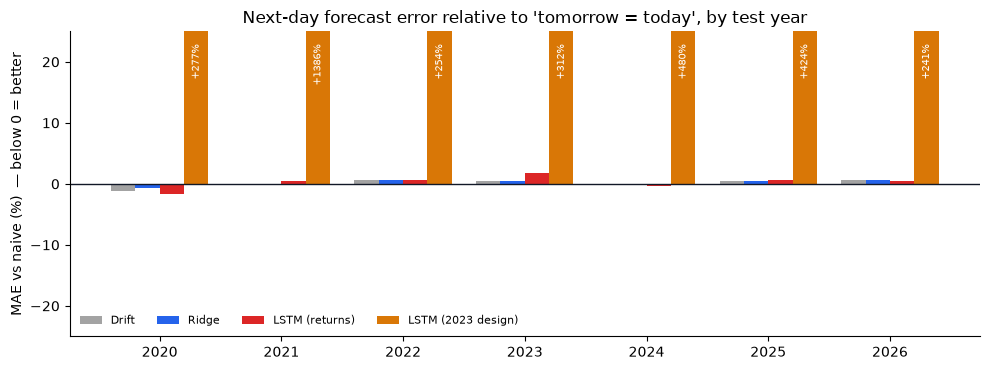

model,Drift,LSTM (2023 design),LSTM (returns),Naive,Ridge
fold,,,,,
2020,256.0,977.0,255.0,259.0,257.0
2021,1397.0,20752.0,1402.0,1397.0,1396.0
2022,656.0,2309.0,656.0,652.0,657.0
2023,440.0,1806.0,446.0,438.0,440.0
2024,1319.0,7646.0,1315.0,1319.0,1318.0
2025,1579.0,8234.0,1580.0,1571.0,1579.0
2026,1367.0,4625.0,1364.0,1358.0,1366.0


In [9]:
plot_relative_mae(by_fold, None)
plt.show()
by_fold.pivot(index="fold", columns="model", values="MAE").round(0)

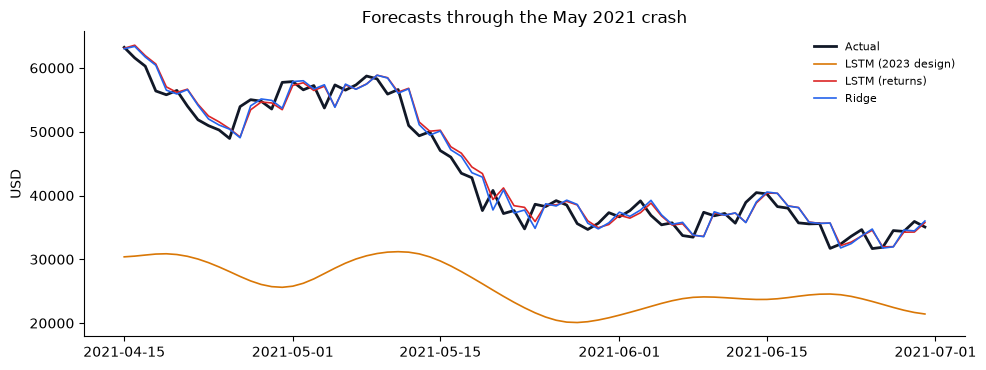

In [10]:
plot_zoom(preds, None)
plt.show()

The zoom shows the pattern behind most "impressive" price-forecast charts. The forecasts track the actual price closely, but they are **shifted one day to the right**. A model that learns "tomorrow ≈ today" looks accurate on a price chart while adding no information, which is why every result here is judged against the naive benchmark rather than by eye.

## Conclusions

1. **Evaluation bugs can hide a model that loses to a trivial baseline.** Once the inverse scaling is fixed, the 2023 LSTM's error was several times that of "tomorrow = today". The original report's 72.95% "accuracy" came from a meaningless metric computed on wrongly scaled prices.
2. **Beating the naive forecast for next-day Bitcoin prices is genuinely hard.** Returns have almost no linear autocorrelation, and the table above shows how each model compares with the naive benchmark, including a significance test.
3. **Predicting returns is the right design for this problem.** Unlike predicting price levels, it doesn't require the model to extrapolate into price ranges it has never seen.

## Possible next steps

- Test whether the LSTM predicts the *size* of moves (volatility) better than their direction; volatility is known to be more predictable than returns.
- Add information that isn't in the price history, such as on-chain activity (Coin Metrics provides active addresses, transaction counts and exchange flows), funding rates or macro indicators.
- Evaluate the forecasts as a trading signal net of transaction costs, which is the test that matters in practice.